# Saving and loading arrays — my revision notes

I wrote these so I can come back and revise without re-learning from scratch.
Each section is: **what I need to remember**, then the code I already ran.

**How to revise**
1. Read the bullets. Cover the code and try to predict the output.
2. Run the cell and check.
3. If I miss it, read only that section again.
4. Finish with the checklist at the bottom.

**Topics in this notebook**
1. Three arrays I save
2. `np.save` writes a `.npy` file
3. `np.load` reads that file back
4. An image is an array: show it, then darken it with `1 - logo`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Three arrays I save

I make three different arrays so I can see that `np.save` keeps whatever is in them.

- `array1` — a known `(2, 3)` table: `[[1, 2, 3], [4, 5, 6]]`. I use this one to check the load.
- `array2` — random floats, shape `(3, 3)`. Values change every run.
- `array3` — zeros, shape `(4, 4)`, dtype float.

In [2]:
array1 = np.array([[1, 2, 3], [4, 5, 6]])
array2 = np.random.rand(3, 3)
array3 = np.zeros((4, 4))

## 2. `np.save` writes a `.npy` file

`np.save("array1.npy", array1)` writes the array to a file named `array1.npy` in the current folder.

`.npy` is NumPy's own binary file. It stores the numbers, the shape, and the dtype. It is not a text file, so opening it in an editor will not look like the printed array.

This cell creates three files: `array1.npy`, `array2.npy`, `array3.npy`. Running it again overwrites those files.

In [7]:
np.save("../data/array1.npy", array1)
np.save("../data/array2.npy", array2)
np.save("../data/array3.npy", array3)

## 3. `np.load` reads the file back

`np.load("array1.npy")` rebuilds the array from the file.
Shape, dtype, and values match what I saved: `(2, 3)` and `[[1, 2, 3], [4, 5, 6]]`.

The name `loaded_array1` is a new variable. Saving did not keep the Python name `array1` inside the file. Only the data is stored.

If the file is missing, `np.load` raises `FileNotFoundError`.

In [4]:
loaded_array1 = np.load("array1.npy")
print("Loaded array 1: \n", loaded_array1)

Loaded array 1: 
 [[1 2 3]
 [4 5 6]]


## 4. An image is an array

`numpy-logo.npy` is a picture stored as an array. `np.load` reads it the same way as any other `.npy` file.

- `plt.subplot(121)` — one row, two columns, left plot. `122` is the right plot.
- `plt.imshow(logo)` — draws the array as an image.
- `dark_logo = 1 - logo` — flips light and dark. This only works when pixel values are between 0 and 1. A bright pixel near `1` becomes near `0`. A dark pixel near `0` becomes near `1`.

The `try` / `except` prints `Numpy Logo File not found` when `numpy-logo.npy` is not in the folder, instead of crashing.

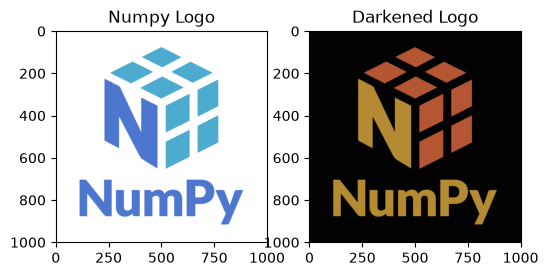

In [6]:
try:
  logo = np.load("../data/numpy-logo.npy")

  # Display the logo
  plt.figure(figsize=(6, 3))
  plt.subplot(121)
  plt.imshow(logo)
  plt.title("Numpy Logo")

  # Darken the logo
  dark_logo = 1 - logo
  plt.subplot(122)
  plt.imshow(dark_logo)
  plt.title("Darkened Logo")
  
except FileNotFoundError:
  print("Numpy Logo File not found")

## Revision checklist

Cover the answers. Say them out loud. Then uncover.

1. What does `np.save` store, and what file extension does it use?
2. Does the `.npy` file remember the Python variable name?
3. What do I call to get the array back, and what error happens if the file is missing?
4. What does `1 - logo` do when pixel values are between 0 and 1?
5. What does `plt.subplot(121)` mean?

<details>
<summary>Answers</summary>

1. The numbers, the shape, and the dtype, in a `.npy` binary file.
2. No. Only the data. I choose a new name when I load it.
3. `np.load("file.npy")`. Missing file → `FileNotFoundError`.
4. It flips light and dark. Bright pixels become dark, and dark pixels become bright.
5. 1 row, 2 columns, position 1 (the left plot).

</details>